## SHAP-Analyse für logistische Regression mit KernelExplainer

Dieses Skript berechnet **SHAP-Werte** für ein logistisches Regressionsmodell auf Basis von **vorhergesagten Wahrscheinlichkeiten** (`predict_proba`) und nutzt dafür eine **Repeated Stratified Cross-Validation**. Ziel ist es, den mittleren Feature-Beitrag über mehrere Folds hinweg robust zu quantifizieren.

### Ablauf

1. Die Excel-Datei wird eingelesen und in Zielvariable (`Verletzungsstatus`) und Prädiktoren aufgeteilt.
2. Das Modell wird über eine wiederholte stratifizierte Cross-Validation trainiert.
3. Kontinuierliche Variablen werden innerhalb jedes Trainingsfolds standardisiert, während die binäre Dummy-Variable `Geschlecht_weiblich` **unskaliert** bleibt.
4. Für jedes Fold wird ein logistisches Regressionsmodell trainiert.
5. Anschließend werden mit dem **SHAP KernelExplainer** SHAP-Werte für die Testdaten berechnet, basierend auf den vorhergesagten Wahrscheinlichkeiten der positiven Klasse.
6. Die SHAP-Werte aller Folds werden zusammengeführt und sowohl als
   - **signed mean SHAP** als auch
   - **absolute mean SHAP**
   über alle Beobachtungen gemittelt.

### Zentrale Ausgabe

Die Funktion liefert unter anderem:

- die Feature-Namen
- den vollständigen SHAP-Stack über alle Testfolds
- die zusammengeführten Testdaten
- fold-spezifische Expected Values
- mittlere signed und absolute SHAP-Werte

### Nutzen

Das Skript dient dazu, die **globale Bedeutung und Richtung einzelner Features** in einem logistisches Regressionsmodell transparent zu machen. Die zusätzliche Prüfung am Ende (`p_model` vs. `p_base + sum(phi_i)`) kontrolliert, ob die SHAP-Zerlegung für ein Beispiel konsistent mit der Modellvorhersage ist.

In [5]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap


def collect_shap_data_lr_probability_kernel(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    kernel_nsamples="auto",
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    df = pd.read_excel(data_path)
    y = df[target_column].astype(int)
    X = df.drop(columns=[target_column])
    features = X.columns.tolist()

    cv = RepeatedStratifiedKFold(
        n_splits=cv_splits,
        n_repeats=cv_repeats,
        random_state=42
    )

    all_shap = []
    all_X = []
    exp_vals_per_fold = []

    last_exp_val = None
    last_model = None
    last_test_len = None

    rng = np.random.default_rng(42)

    dummy_col = "Geschlecht_weiblich"
    keep_unscaled = [dummy_col] if dummy_col in X.columns else []

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose:
            print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train = y.iloc[train_idx]

        cols_to_scale = [c for c in X_train.columns if c not in keep_unscaled]

        X_train_s = X_train.copy()
        X_test_s = X_test.copy()

        scaler = StandardScaler()
        X_train_s[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
        X_test_s[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

        X_train_s = X_train_s.values
        X_test_s = X_test_s.values

        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None),
            random_state=42
        )
        lr.fit(X_train_s, y_train)

        classes = lr.classes_
        pos_idx = int(np.where(classes == 1)[0][0])

        f = lambda A: lr.predict_proba(A)[:, pos_idx]

        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.KernelExplainer(f, bg)
        phi = expl.shap_values(X_test_s, nsamples=kernel_nsamples)

        if isinstance(phi, list):
            vals = phi[pos_idx]
        else:
            vals = phi

        ev = expl.expected_value
        if isinstance(ev, (list, tuple, np.ndarray)):
            exp_val = float(np.ravel(ev)[pos_idx])
        else:
            exp_val = float(ev)

        vals = np.nan_to_num(vals, nan=0.0, posinf=0.0, neginf=0.0)

        all_shap.append(vals)
        all_X.append(X_test_s)
        exp_vals_per_fold.append(exp_val)

        last_model = lr
        last_test_len = X_test_s.shape[0]
        last_exp_val = exp_val

    shap_stack = np.vstack(all_shap)
    X_stack = np.vstack(all_X)

    signed_mean_shaps = np.nanmean(shap_stack, axis=0)
    abs_mean_shaps = np.nanmean(np.abs(shap_stack), axis=0)

    return (
        features,
        shap_stack,
        X_stack,
        exp_vals_per_fold,
        signed_mean_shaps,
        abs_mean_shaps,
        last_exp_val,
        last_model,
        last_test_len
    )

features, shap_stack, X_stack, exp_vals_per_fold, signed_mean_shaps, abs_mean_shaps, last_exp_val, last_model, last_test_len = \
    collect_shap_data_lr_probability_kernel(
        r"K:\Team\Böhmer_Michael\PAPER\Philipp\Datensatz\ML_Datasets\dataset_stable70.xlsx",
        cv_splits=5,
        cv_repeats=10,
        shap_background_size=100,
        kernel_nsamples="auto",
        verbose=True
    )
i = len(X_stack) - last_test_len
print("p_model:", float(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1]))
print("p_base + sum(phi_i):", float(last_exp_val + shap_stack[i].sum()))

Fold 1


  0%|          | 0/17 [00:00<?, ?it/s]

Fold 2


  0%|          | 0/17 [00:00<?, ?it/s]

Fold 3


...

Fold 49


  0%|          | 0/16 [00:00<?, ?it/s]

Fold 50


  0%|          | 0/16 [00:00<?, ?it/s]

p_model: 0.4383551115937666
p_base + sum(phi_i): 0.4383551115937666


## Konsistenzprüfung der SHAP-Zerlegung

Dieser kurze Prüfblock überprüft, ob die mit SHAP berechneten Feature-Beiträge die Modellvorhersage korrekt rekonstruieren. Dafür werden einige zufällig ausgewählte Beobachtungen aus dem **letzten Cross-Validation-Fold** herangezogen.

### Ablauf

1. Aus dem letzten Fold werden zufällig bis zu fünf Testbeobachtungen ausgewählt.
2. Für jede Beobachtung wird die vorhergesagte Wahrscheinlichkeit auf zwei Arten bestimmt:
   - direkt aus dem Modell (`predict_proba`)
   - rekonstruiert aus **Expected Value + Summe der SHAP-Werte**
3. Anschließend wird die Differenz zwischen beiden Werten berechnet.

### Ausgabe und Nutzen

Der Code gibt die maximale, mittlere und mediane Abweichung sowie die Einzelwerte pro Testbeobachtung aus. Sehr kleine Differenzen zeigen, dass die SHAP-Zerlegung numerisch konsistent mit der Modellvorhersage ist und die Beiträge korrekt auf die vorhergesagte Wahrscheinlichkeit aufsummiert werden.

In [6]:
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap = []
p_from_model = []

for i in idx_local:
    p_i = last_exp_val + shap_stack[i].sum()   # direkt Probability rekonstruieren
    p_from_shap.append(p_i)
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model

print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples, Probability) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")


=== SHAP Selbsttest (letzter Fold, Zufalls-Samples, Probability) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 1.110e-16
Mittlere Abweichung : 3.417e-17
Median Abweichung   : 1.821e-17

P_SHAP=0.006462 | P_Modell=0.006462 | Δ=-1.82e-17
P_SHAP=0.330934 | P_Modell=0.330934 | Δ=+0.00e+00
P_SHAP=0.235574 | P_Modell=0.235574 | Δ=-2.78e-17
P_SHAP=0.996577 | P_Modell=0.996577 | Δ=+1.11e-16
P_SHAP=0.104674 | P_Modell=0.104674 | Δ=+1.39e-17


## Lokaler SHAP-Waterfall-Plot für einzelne Beobachtungen

Dieses Skript erzeugt eine **lokale SHAP-Erklärung** für eine einzelne Beobachtung und kombiniert einen eigenen Header mit dem eigentlichen **SHAP-Waterfall-Plot** in einer gemeinsamen Grafik. Ziel ist eine klarere und präsentationsfähige Darstellung der lokalen Modellentscheidung.

### Ablauf

1. Für eine ausgewählte Beobachtung werden die SHAP-Werte aus dem bereits berechneten `shap_stack` geladen.
2. Optional können Features mit exakt `0` Beitrag zu einer Sammelkategorie zusammengefasst werden.
3. Aus den SHAP-Werten und dem Base Value wird eine `shap.Explanation` in **Probability-Einheiten** erstellt.
4. Es werden zwei Teilgrafiken erzeugt:
   - ein eigener Header mit Baseline und finaler Vorhersagewahrscheinlichkeit
   - der eigentliche SHAP-Waterfall-Plot
5. Beide Grafiken werden temporär als PNG gespeichert, anschließend mit `PIL` zu einem einzigen Bild kombiniert und gemeinsam angezeigt.

### Zentrale Inhalte

Die Darstellung zeigt:
- die **Basiswahrscheinlichkeit** `E[f(x)]`
- die **individuelle Vorhersage** `f(x)`
- die Beiträge einzelner Features, die die Vorhersage zur verletzten oder nicht verletzten Klasse verschieben

### Nutzen

Der Plot dient der **lokalen Interpretierbarkeit** einzelner Modellentscheidungen. Durch den zusätzlichen Header wird die SHAP-Grafik leichter lesbar und besser für Berichte, Präsentationen oder Fallbeispiele nutzbar.

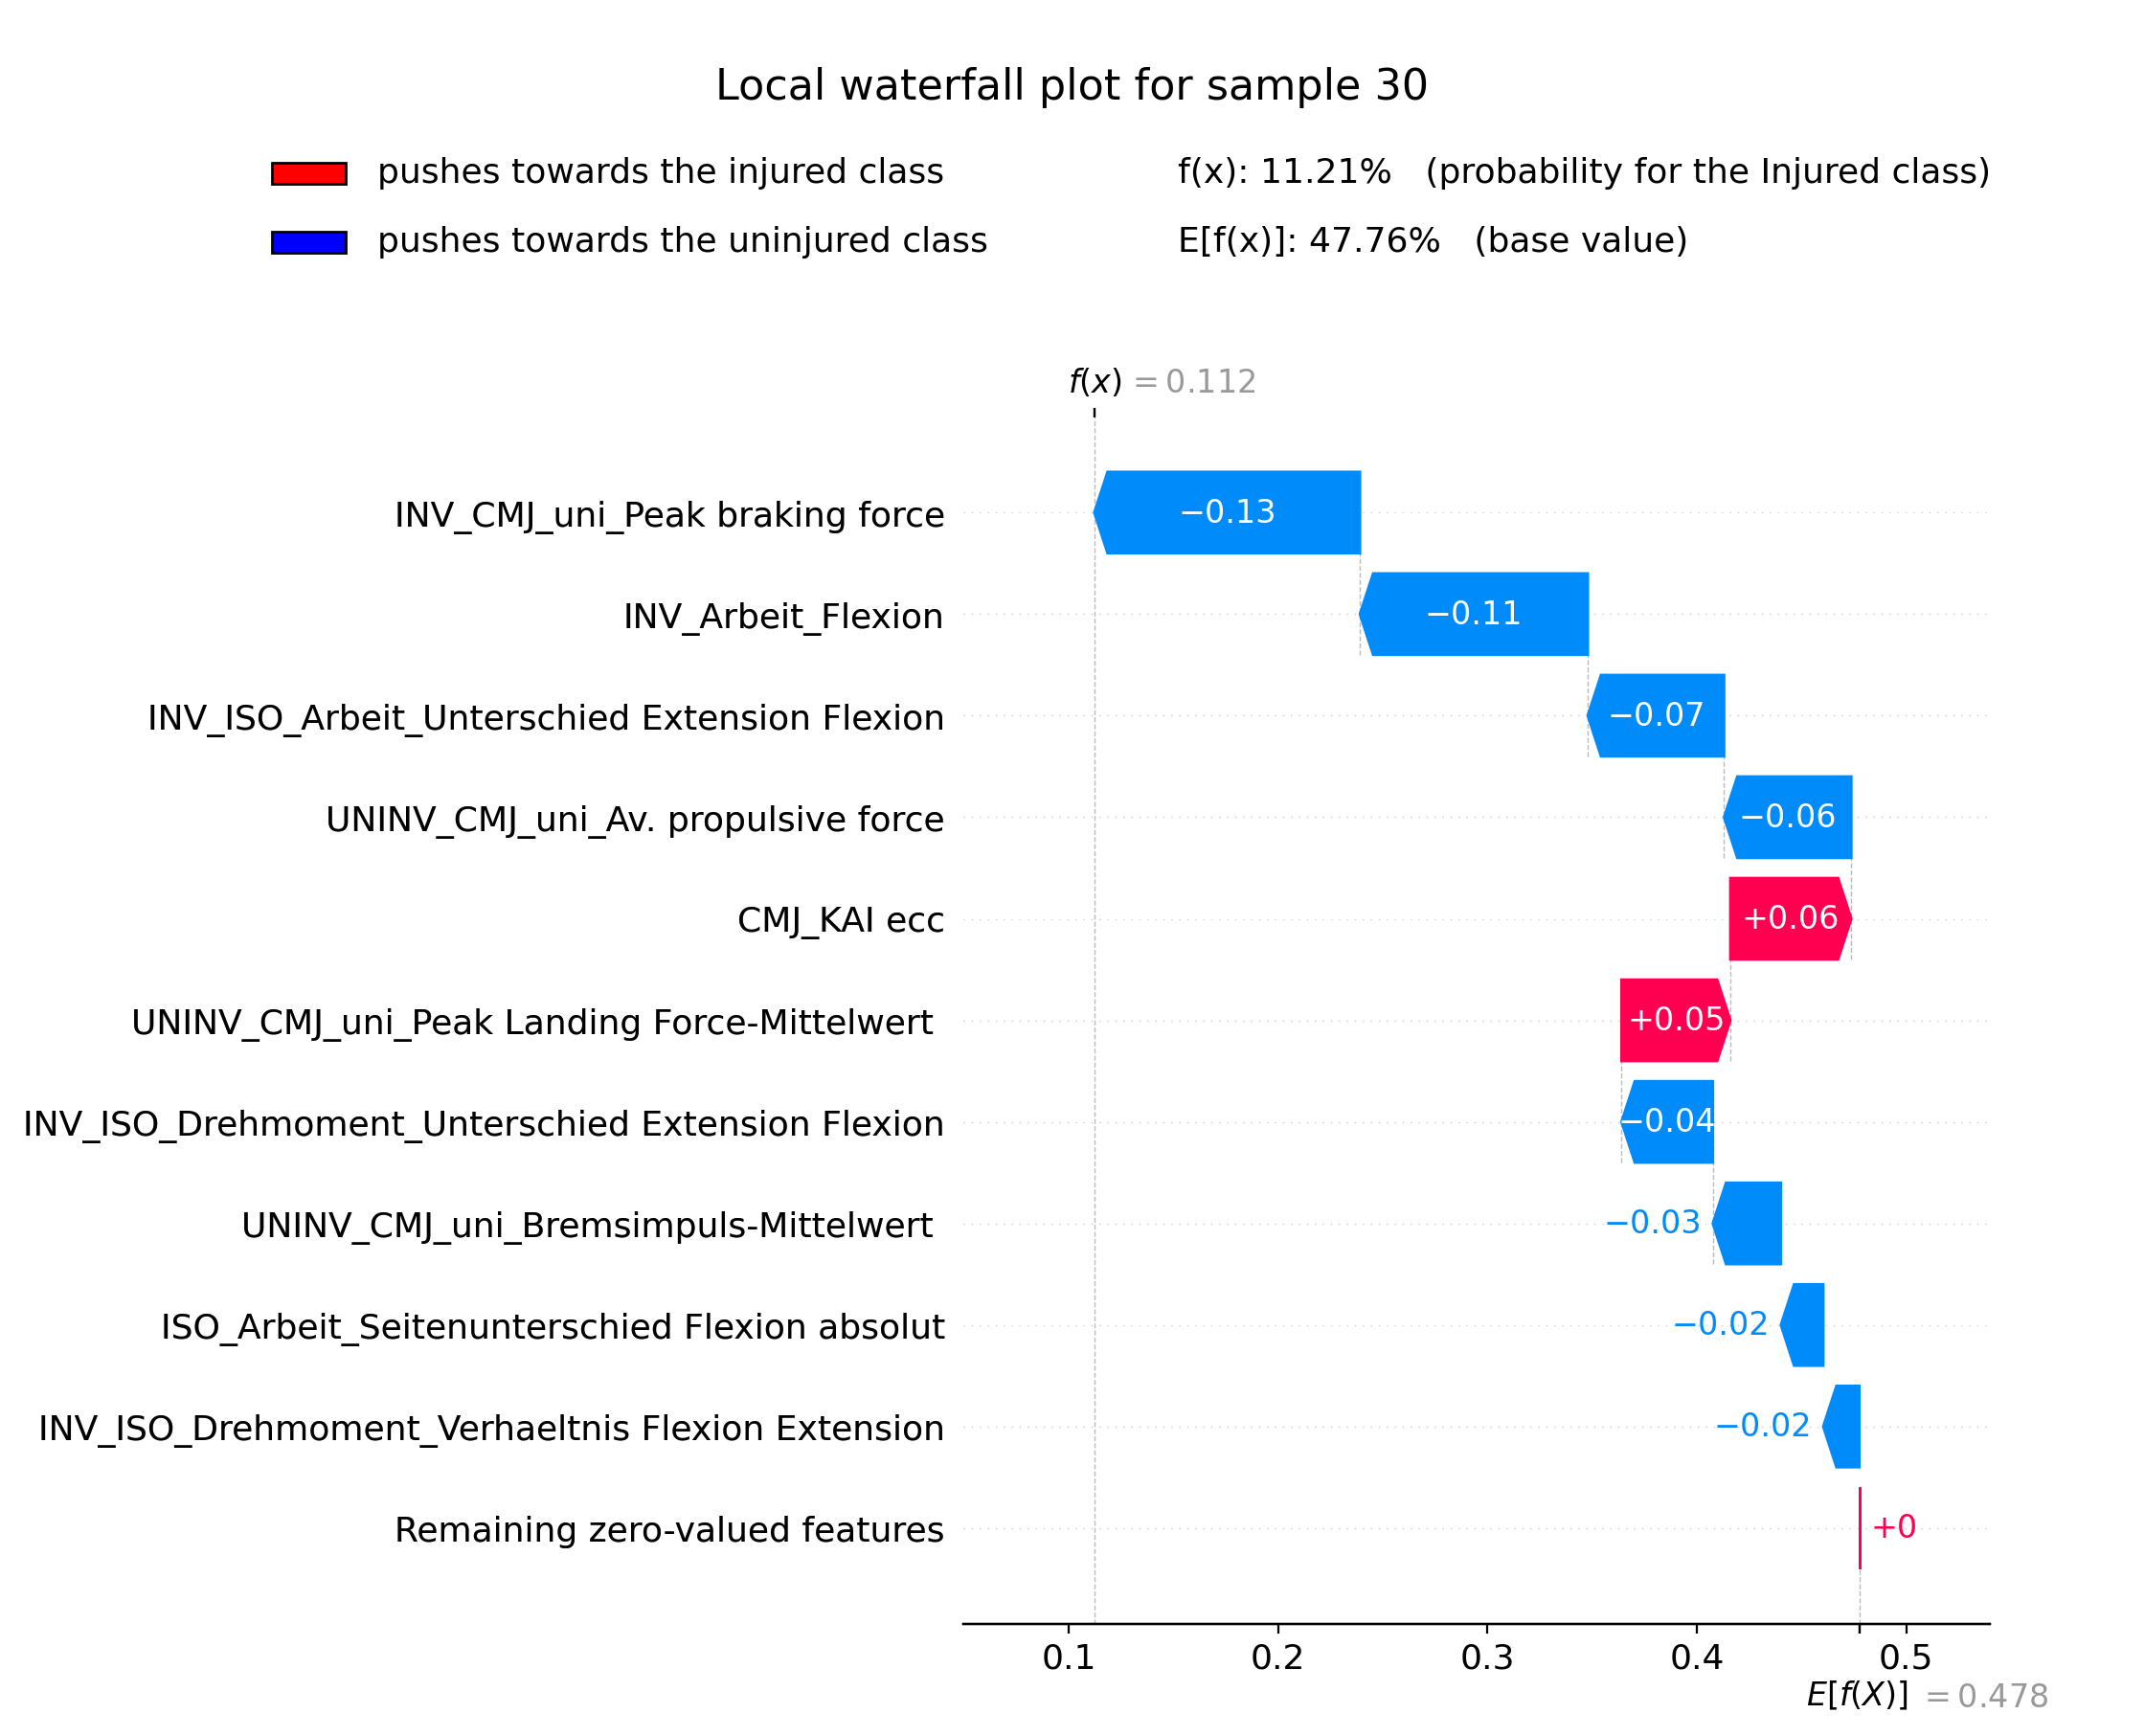

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from io import BytesIO
import tempfile, os
from PIL import Image
import shap

def _clamp01(x: float) -> float:
    return float(min(1.0, max(0.0, x)))

def plot_local_waterfall_combined_tempfiles(
    features,
    shap_stack,
    exp_val,              # Baseline-Probability (Klasse 1)
    sample_idx=None,
    combine_zeros=True,
    max_display=None,
    # Geometrie
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200,
    spacer_px=0
):
    # ----- Sample & Explanation vorbereiten -----
    if sample_idx is None:
        rng = np.random.default_rng(42)
        sample_idx = int(rng.integers(0, shap_stack.shape[0]))

    vals_full  = shap_stack[sample_idx, :]   # ΔProbability pro Feature
    names_full = list(features)

    if combine_zeros:
        nz = vals_full != 0
        vals  = vals_full[nz].tolist()
        names = [names_full[i] for i in range(len(names_full)) if nz[i]]
        if (~nz).sum() > 0:
            names.append("Remaining zero-valued features"); vals.append(0.0)
    else:
        vals, names = vals_full.tolist(), names_full

    # SHAP Explanation in Probability-Einheiten
    exp = shap.Explanation(values=np.array(vals),
                           base_values=float(exp_val),   # Baseline p
                           feature_names=names)

    # --- Wahrscheinlichkeiten direkt additiv ---
    p_base = float(exp.base_values)
    p_fx   = float(exp.base_values + float(np.sum(exp.values)))
    # numerische Toleranzen vorsichtig auf [0,1] clampen
    p_base = _clamp01(p_base)
    p_fx   = _clamp01(p_fx)

    # ===== 1) Header-Plot -> temporäre PNG (ohne tight) =====
    figA = plt.figure(figsize=(width, header_height), dpi=dpi)
    axA = figA.add_axes([0, 0, 1, 1]); axA.axis("off")

    axA.text(0.5, 0.80, f"Local waterfall plot for sample {sample_idx}",
             ha="center", va="center", fontsize=16)

    x_left_patch, x_left_text, x_right_col = 0.12, 0.17, 0.55
    y1, y2 = 0.55, 0.35
    box_w, box_h = 0.035, 0.06

    axA.add_patch(Rectangle((x_left_patch, y1 - box_h/2), box_w, box_h,
                            facecolor="red", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y1, "pushes towards the injured class",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y1,
             f"f(x): {p_fx:,.2%}   (probability for the Injured class)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    axA.add_patch(Rectangle((x_left_patch, y2 - box_h/2), box_w, box_h,
                            facecolor="blue", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y2, "pushes towards the uninjured class",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y2,
             f"E[f(x)]: {p_base:,.2%}   (base value)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    tmpA = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpA.close()
    figA.savefig(tmpA.name, format="png", dpi=dpi, facecolor=figA.get_facecolor(),
                 bbox_inches=None, pad_inches=0)
    plt.close(figA)

    # ===== 2) Waterfall-Plot -> temporäre PNG (ohne tight) =====
    n_rows = len(exp.values) if max_display is None else min(max_display, len(exp.values))
    heightB = base_height + row_height * n_rows

    figB = plt.figure(figsize=(width, heightB), dpi=dpi)
    shap.plots.waterfall(
        exp,
        show=False,
        max_display=(len(exp.values) if max_display is None else max_display)
    )
    # Ränder feinjustieren, damit Labels nicht abgeschnitten werden
    plt.gcf().subplots_adjust(left=left, right=right, top=top, bottom=bottom)

    tmpB = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpB.close()
    figB = plt.gcf()
    figB.canvas.draw()
    figB.savefig(tmpB.name, format="png", dpi=dpi, facecolor=figB.get_facecolor(),
                 bbox_inches="tight", pad_inches=0.02)
    plt.close(plt.gcf())

    # ===== 3) Beide PNGs laden & exakt untereinander packen =====
    imgA = Image.open(tmpA.name).convert("RGBA")
    imgB = Image.open(tmpB.name).convert("RGBA")

    # optionaler weißer Spacer
    spacer = None
    if spacer_px > 0:
        spacer = Image.new("RGBA", (max(imgA.width, imgB.width), spacer_px), (255, 255, 255, 255))

    # gleiche Breite herstellen durch weißes Padding (keine Skalierung)
    W = max(imgA.width, imgB.width)
    if imgA.width != W:
        pad = Image.new("RGBA", (W - imgA.width, imgA.height), (255, 255, 255, 255))
        imgA = Image.fromarray(np.hstack([np.array(imgA), np.array(pad)]))
    if imgB.width != W:
        pad = Image.new("RGBA", (W - imgB.width, imgB.height), (255, 255, 255, 255))
        imgB = Image.fromarray(np.hstack([np.array(imgB), np.array(pad)]))

    parts = [imgA]
    if spacer is not None: parts.append(spacer)
    parts.append(imgB)

    total_h = sum(p.height for p in parts)
    combo = Image.new("RGBA", (W, total_h), (255, 255, 255, 255))
    y = 0
    for p in parts:
        combo.paste(p, (0, y))
        y += p.height

    # ===== 4) Nur EIN Bild anzeigen =====
    combo_np = np.asarray(combo)[..., :3]  # RGB
    h_px, w_px = combo_np.shape[:2]
    fig = plt.figure(figsize=(w_px / dpi, h_px / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off")
    ax.imshow(combo_np, interpolation="none")
    plt.show()

    # Temp-Dateien aufräumen
    try:
        os.remove(tmpA.name); os.remove(tmpB.name)
    except Exception:
        pass

# --- Aufruf ---
last_fold_start = len(X_stack) - last_test_len
sample_idx = 30  # gewünschtes Sample

plot_local_waterfall_combined_tempfiles(
    features=features,
    shap_stack=shap_stack,
    exp_val=last_exp_val,
    sample_idx=sample_idx,
    combine_zeros=True,
    max_display=None,
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200, spacer_px=0
)
